# Release Operations and Observability Research

Date: 2026-05-23

## Feature Hypothesis

**Idea**: Define the minimum post-release operations stack for Vibe-to-MIDI: crash/error capture, Android vitals monitoring, update rollback/fix-forward process, performance visibility, feature flags, purchase operations, and support/debug workflows.

**Target user / operator**: The solo developer/operator of an Android-first Expo app that includes custom native modules (`react-native-audio-api`, `expo-video`) and may later add Pro entitlement and billing.

**Problem**: After release, the app needs to detect crashes, ANRs, bad OTA updates, performance regressions, billing issues, and user-impacting defects quickly. The stack must avoid over-collecting user data and avoid adding unnecessary native dependencies before release/privacy work is ready.

**MVP scope**:
- Recommend a practical operations stack for the first public Android release.
- Separate must-have launch tools from later integrations.
- Include privacy/security guardrails and what should not be added yet.
- Produce a prioritized implementation plan.

**Non-goals**:
- No immediate implementation in app code.
- No real service credentials, DSNs, Firebase config files, Play signing material, or tokens committed.
- No paid plan or billing SDK integration unless explicitly started later.
- No full customer support platform selection unless needed for MVP.

**Research questions**:
1. What should be installed before the first production release?
2. Which tools are redundant, and which should be combined?
3. Should the app choose Sentry, Firebase Crashlytics, EAS Observe/Insights, or a staged combination?
4. How should bad releases and OTA updates be handled?
5. What privacy and operational risks should be documented before adding analytics/monitoring?

## Source Notes

- Expo Sentry guide, https://docs.expo.dev/guides/using-sentry/ — Sentry wizard configures Expo/React Native; EAS Build can upload source maps with `SENTRY_AUTH_TOKEN`; EAS Update source maps need upload after update publish.
- Sentry React Native/Expo docs, https://docs.sentry.io/platforms/react-native/ — supports JS/native error reporting, releases, source maps, breadcrumbs, and release health for React Native apps.
- EAS Update error recovery, https://docs.expo.dev/eas-update/error-recovery/ — Expo Updates can reduce app-bricking risk and supports rollback/fix-forward behavior, but it is not a complete safety net.
- EAS Update debugging/deployment docs, https://docs.expo.dev/eas-update/debug/ and https://docs.expo.dev/eas-update/deployment/ — update pages expose which update/build is running; rollouts can gradually ship updates and `republish` can undo bad updates.
- EAS Insights, https://docs.expo.dev/eas-insights/introduction — preview service using `expo-insights`; useful for coarse usage/cold-start visibility, but preview status means it should not be the only observability tool.
- EAS Observe metrics, https://docs.expo.dev/eas/observe/reference/metrics/ and setup, https://docs.expo.dev/eas/observe/get-started/ — production performance metrics such as cold/warm launch and TTI; as of the checked docs it requires SDK 55+ and private-preview access.
- Firebase Crashlytics product/docs, https://firebase.google.com/products/crashlytics and https://firebase.google.com/docs/crashlytics/get-started — mature crash/ANR reporting with alerts, logs, keys, and Android Studio/App Quality Insights integration.
- Google Play Android vitals, https://support.google.com/googleplay/android-developer/answer/9859174 — Play Console reports crashes/ANRs from opted-in devices; user-perceived crash and ANR rates are core vitals that affect discoverability.
- Firebase Remote Config, https://firebase.google.com/docs/remote-config/ — can change app behavior/feature flags without publishing an app update and supports rollouts/experiments, but adds Firebase operational/privacy surface.
- RevenueCat webhooks, https://www.revenuecat.com/docs/integrations/webhooks — useful later for purchase lifecycle operations; needs secure webhook endpoint and is tied to RevenueCat plan/Pro integration.
- Repository guardrails, `.agents/security-ci-release.md` — do not add analytics/Firebase/Play submission automation/signing setup until the user explicitly starts release/privacy work; keep `tsc` and Jest passing.

## Data / Analysis

The following scores are directional for this Android-first Expo app. They are not vendor ratings.

Scale: 1 = weak / low, 5 = strong / high. `risk_cost` combines integration complexity, privacy surface, and maintenance burden.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path.cwd()
base = notebook_dir.parent if notebook_dir.name == "notebooks" else Path("research/features/2026-05-23_release-operations-observability")
figures = base / "figures"
figures.mkdir(parents=True, exist_ok=True)

tools = pd.DataFrame([
    {"tool": "Sentry", "category": "crash/error reporting", "launch_value": 5, "expo_fit": 5, "android_fit": 4, "privacy_control": 4, "risk_cost": 3, "recommendation": "Build first", "notes": "Best first app-side error capture; source maps for EAS Build/Update; avoid PII breadcrumbs."},
    {"tool": "Google Play Android vitals", "category": "store technical quality", "launch_value": 5, "expo_fit": 5, "android_fit": 5, "privacy_control": 5, "risk_cost": 1, "recommendation": "Use at launch", "notes": "No SDK needed; monitor user-perceived crash/ANR rates and Play discoverability risk."},
    {"tool": "EAS Update rollouts + republish", "category": "release mitigation", "launch_value": 5, "expo_fit": 5, "android_fit": 4, "privacy_control": 5, "risk_cost": 2, "recommendation": "Build for JS-only releases", "notes": "Strong fix-forward/rollback tool; must respect native runtime boundaries and test staging updates."},
    {"tool": "Firebase Crashlytics", "category": "crash/ANR reporting", "launch_value": 4, "expo_fit": 3, "android_fit": 5, "privacy_control": 3, "risk_cost": 4, "recommendation": "Defer or choose instead of Sentry", "notes": "Mature Android crash/ANR stack; adds Firebase config/native setup. Useful if Firebase is already adopted."},
    {"tool": "EAS Insights", "category": "usage/startup visibility", "launch_value": 3, "expo_fit": 5, "android_fit": 3, "privacy_control": 4, "risk_cost": 2, "recommendation": "Consider later", "notes": "Preview and limited event scope; useful with EAS but not enough for crash triage."},
    {"tool": "EAS Observe", "category": "performance metrics", "launch_value": 3, "expo_fit": 3, "android_fit": 3, "privacy_control": 4, "risk_cost": 3, "recommendation": "Defer", "notes": "Useful for startup/TTI when SDK/access fit; current project SDK may not meet requirement."},
    {"tool": "Firebase Remote Config", "category": "feature flags/kill switches", "launch_value": 3, "expo_fit": 3, "android_fit": 4, "privacy_control": 3, "risk_cost": 4, "recommendation": "Defer until feature flags are necessary", "notes": "Powerful for kill switches and rollouts, but adds Firebase surface; local defaults are enough before launch."},
    {"tool": "RevenueCat webhooks", "category": "billing operations", "launch_value": 2, "expo_fit": 3, "android_fit": 4, "privacy_control": 3, "risk_cost": 4, "recommendation": "Defer until billing", "notes": "Only relevant when Pro billing ships; requires backend endpoint and idempotent processing."},
])

tools["priority_score"] = tools["launch_value"] + tools["expo_fit"] + tools["android_fit"] + tools["privacy_control"] - tools["risk_cost"]
tools.sort_values("priority_score", ascending=False)

,tool,category,launch_value,expo_fit,android_fit,privacy_control,risk_cost,recommendation,notes,priority_score
1,Google Play Android vitals,store technical quality,5,5,5,5,1,Use at launch,No SDK needed; monitor user-perceived crash/AN...,19
2,EAS Update rollouts + republish,release mitigation,5,5,4,5,2,Build for JS-only releases,Strong fix-forward/rollback tool; must respect...,17
0,Sentry,crash/error reporting,5,5,4,4,3,Build first,Best first app-side error capture; source maps...,15
4,EAS Insights,usage/startup visibility,3,5,3,4,2,Consider later,Preview and limited event scope; useful with E...,13
3,Firebase Crashlytics,crash/ANR reporting,4,3,5,3,4,Defer or choose instead of Sentry,Mature Android crash/ANR stack; adds Firebase ...,11
5,EAS Observe,performance metrics,3,3,3,4,3,Defer,Useful for startup/TTI when SDK/access fit; cu...,10
6,Firebase Remote Config,feature flags/kill switches,3,3,4,3,4,Defer until feature flags are necessary,"Powerful for kill switches and rollouts, but a...",9
7,RevenueCat webhooks,billing operations,2,3,4,3,4,Defer until billing,Only relevant when Pro billing ships; requires...,8


'/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-23_release-operations-observability/figures/operations-tool-priority.png'

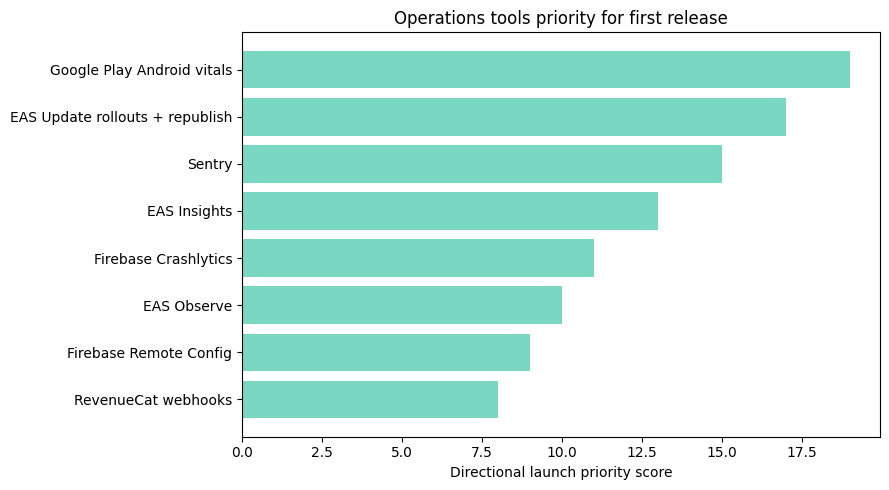

In [2]:
chart = tools.sort_values("priority_score", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(chart["tool"], chart["priority_score"], color="#79d7c2")
plt.xlabel("Directional launch priority score")
plt.title("Operations tools priority for first release")
plt.tight_layout()
path = figures / "operations-tool-priority.png"
plt.savefig(path, dpi=160)
path.as_posix()

In [3]:
ops_layers = pd.DataFrame([
    {"layer": "Required before public release", "items": "Sentry, Play Android vitals, release checklist, privacy policy update, source-map upload path", "why": "Detect crashes and JS/native errors with actionable stack traces; monitor Play technical quality."},
    {"layer": "Required if using EAS Update", "items": "staging update channel, rollout percentage, republish runbook, runtimeVersion policy", "why": "Avoid bricking users and support fast fix-forward while respecting native compatibility."},
    {"layer": "Manual first", "items": "support email, issue template, version/build/update id shown in Settings or debug screen", "why": "Low complexity; enough for early testers and privacy-light support."},
    {"layer": "Defer", "items": "Firebase Crashlytics/Remote Config/Analytics, EAS Observe, RevenueCat webhooks", "why": "Useful later, but adds privacy, native config, billing, or SDK-version complexity."},
])
ops_layers

,layer,items,why
0,Required before public release,"Sentry, Play Android vitals, release checklist...",Detect crashes and JS/native errors with actio...
1,Required if using EAS Update,"staging update channel, rollout percentage, re...",Avoid bricking users and support fast fix-forw...
2,Manual first,"support email, issue template, version/build/u...",Low complexity; enough for early testers and p...
3,Defer,"Firebase Crashlytics/Remote Config/Analytics, ...","Useful later, but adds privacy, native config,..."


In [4]:
release_runbook = pd.DataFrame([
    {"moment": "Before release", "action": "Run typecheck, Jest, Android dev-build smoke test, release build install, audio/video playback test", "owner_note": "Must include device test because audio/video native modules cannot be proven in Jest."},
    {"moment": "Before release", "action": "Confirm Sentry sourcemap upload for EAS Build and any EAS Update path", "owner_note": "Without source maps, JS stack traces are much less actionable."},
    {"moment": "Before release", "action": "Update privacy policy and in-app license notices for any monitoring SDK", "owner_note": "Do this before collecting diagnostics or analytics."},
    {"moment": "Release day", "action": "Watch Sentry new issues, Play Android vitals, store pre-launch report, install/update success", "owner_note": "Prioritize foreground user-perceived crashes and ANRs."},
    {"moment": "Bad JS-only update", "action": "Use EAS Update republish or fix-forward after staging verification", "owner_note": "Rollback can be unsafe if persistent state changed; fix-forward if unsure."},
    {"moment": "Bad native build", "action": "Stop rollout in Play Console / ship new build; do not rely on OTA if native layer changed", "owner_note": "Native dependency changes require store build."},
    {"moment": "Support report", "action": "Ask for app version, build number, Android model/version, reproduction steps, and whether audio/video is involved", "owner_note": "Avoid collecting personal media unless required and consented."},
])
release_runbook

,moment,action,owner_note
0,Before release,"Run typecheck, Jest, Android dev-build smoke t...",Must include device test because audio/video n...
1,Before release,Confirm Sentry sourcemap upload for EAS Build ...,"Without source maps, JS stack traces are much ..."
2,Before release,Update privacy policy and in-app license notic...,Do this before collecting diagnostics or analy...
3,Release day,"Watch Sentry new issues, Play Android vitals, ...",Prioritize foreground user-perceived crashes a...
4,Bad JS-only update,Use EAS Update republish or fix-forward after ...,Rollback can be unsafe if persistent state cha...
5,Bad native build,Stop rollout in Play Console / ship new build;...,Native dependency changes require store build.
6,Support report,"Ask for app version, build number, Android mod...",Avoid collecting personal media unless require...


## Decision Summary

**Recommendation: Narrow / Build first layer.**

For the first public release, build a small operations layer rather than a full analytics platform. The recommended launch stack is:

1. **Sentry for app-side crash/error reporting**
   - Best first integration for Expo/React Native because it covers JS errors and can symbolicate EAS Build/EAS Update stacks when source maps are uploaded.
   - Add release/update metadata early.
   - Keep breadcrumbs and tags privacy-safe; do not record vibe text or user-created content unless explicitly designed and disclosed.

2. **Google Play Android vitals as the store-quality source of truth**
   - No runtime SDK required.
   - Monitor user-perceived crash and ANR rates because they affect Play quality/discoverability.

3. **EAS Update runbook only if OTA updates are enabled**
   - Use staging channel, rollout percentage, and `republish`/fix-forward process.
   - Do not treat error recovery as a complete safety net. Native module changes still require a new store build.

4. **Manual support workflow for MVP**
   - Support email, minimal report template, and visible app version/build/update id in Settings/Debug.
   - This is enough before adding heavy product analytics.

**Defer**:
- Firebase Crashlytics: strong Android choice, but avoid installing both Sentry and Crashlytics at launch unless there is a clear need. Consider it if the project later adopts Firebase or needs deeper Android Studio/Crashlytics workflow.
- Firebase Remote Config: useful for kill switches and feature flags, but defer until there is a concrete remotely-controlled feature. Local config and EAS Update are enough before launch.
- Firebase Analytics / product analytics: defer until a privacy plan and event schema exist.
- EAS Observe: promising for production startup/TTI, but defer until SDK/access fit and after the basic crash stack is live.
- RevenueCat webhooks: defer until real Pro billing implementation.

**Risks**:
- Monitoring SDKs can accidentally collect identifiers or content; update privacy policy and define redaction rules before installation.
- Source maps require secret tokens; never commit `SENTRY_AUTH_TOKEN` or service credentials.
- EAS Update rollback is not always safe after persistent-state changes.
- Audio/video failures may be device-specific; keep manual Android smoke tests even with monitoring.
- Adding Firebase solely for operations increases native setup complexity and config-file secret handling.

**Next step**:
Implement a release-prep task, not a broad operations platform: add Sentry with release/source-map configuration, add a privacy-safe error boundary/reporting wrapper, add Settings/Debug version metadata, and document the release incident runbook.

## Open Questions

- Will the first release use EAS Update, or only store builds? This changes the required rollback/source-map workflow.
- Which privacy policy wording will cover crash diagnostics, device metadata, and optional support emails?
- Do we need product analytics before launch, or can early usage be inferred from store installs, support reports, and crash-free sessions?
- Should Sentry be self-hosted/region-configured or SaaS default?
- What support contact and response process should be published in Play Console?
- If Pro billing ships, will RevenueCat be used, and is a backend webhook endpoint planned?